In [18]:
import pandas as pd

df = pd.read_csv("../../SOURCES_AND_DATASHEETS/usgs_data_USGS-01646500_20260705_151214.csv")

df

,Unnamed: 0,gage_height_ft,streamflow_cfs,dissolved_oxygen_mg_l,pH,specific_conductance_us_cm,temperature_c,turbidity_fnu,precipitation,rain,snowfall,snow_depth,soil_moisture_0_to_1cm,soil_moisture_1_to_3cm,temperature_2m,wind_speed_10m,vapour_pressure_deficit,precip_3hr,precip_24hr,precip_72hr
0,2025-07-05 00:00:00+00:00,NaN,NaN,7.3,8.2,314.0,27.9,15.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-05 04:00:00+00:00,NaN,NaN,7.3,8.2,314.0,27.9,15.5,0.0,0.0,0.0,0.0,NaN,NaN,20.95,5.315336,0.541649,NaN,NaN,NaN
2,2025-07-05 05:00:00+00:00,NaN,NaN,7.3,8.2,314.0,27.9,15.5,0.0,0.0,0.0,0.0,NaN,NaN,20.65,4.693826,0.502440,NaN,NaN,NaN
3,2025-07-05 06:00:00+00:00,NaN,NaN,7.3,8.2,314.0,27.9,15.5,0.0,0.0,0.0,0.0,NaN,NaN,20.45,2.052316,0.466487,NaN,NaN,NaN
4,2025-07-05 07:00:00+00:00,NaN,NaN,7.3,8.2,314.0,27.9,15.5,0.0,0.0,0.0,0.0,NaN,NaN,20.05,1.659518,0.407799,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104135,2026-07-05 23:00:00+00:00,NaN,NaN,12.3,8.2,358.0,32.5,4.7,0.8,0.8,0.0,0.0,NaN,NaN,27.70,13.523978,1.086545,0.8,26.6,35.0
104136,2026-07-06 00:00:00+00:00,NaN,NaN,12.3,8.2,358.0,32.5,4.7,0.1,0.1,0.0,0.0,NaN,NaN,27.10,3.536439,0.827449,0.9,26.7,35.1
104137,2026-07-06 01:00:00+00:00,NaN,NaN,12.3,8.2,358.0,32.5,4.7,0.0,0.0,0.0,0.0,NaN,NaN,26.25,3.054701,0.584963,0.9,26.7,35.1
104138,2026-07-06 02:00:00+00:00,NaN,NaN,12.3,8.2,358.0,32.5,4.7,0.0,0.0,0.0,0.0,NaN,NaN,25.80,2.995797,0.469702,0.9,26.7,35.1


array([[<Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'gage_height_ft'}>,
        <Axes: title={'center': 'streamflow_cfs'}>,
        <Axes: title={'center': 'dissolved_oxygen_mg_l'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'specific_conductance_us_cm'}>,
        <Axes: title={'center': 'temperature_c'}>,
        <Axes: title={'center': 'turbidity_fnu'}>],
       [<Axes: title={'center': 'precipitation'}>,
        <Axes: title={'center': 'rain'}>,
        <Axes: title={'center': 'temperature_2m'}>,
        <Axes: title={'center': 'wind_speed_10m'}>],
       [<Axes: title={'center': 'vapour_pressure_deficit'}>,
        <Axes: title={'center': 'precip_3hr'}>,
        <Axes: title={'center': 'precip_24hr'}>,
        <Axes: title={'center': 'precip_72hr'}>],
       [<Axes: title={'center': 'is_raining'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

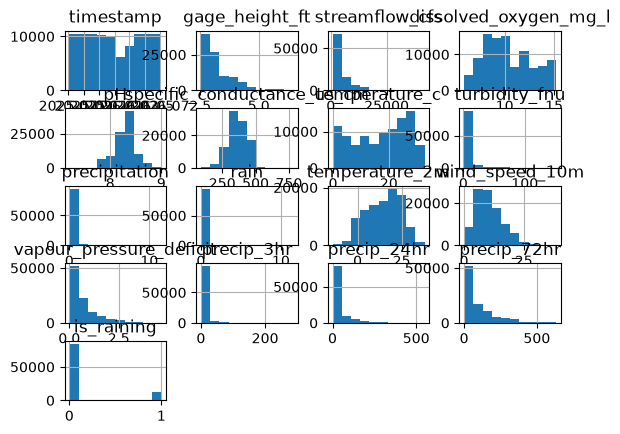

In [19]:
# preprocessing
df = df.dropna(subset=['streamflow_cfs', 'precipitation'])

df = df.drop(columns=['snowfall', 'snow_depth', 'soil_moisture_0_to_1cm', 'soil_moisture_1_to_3cm'])

df = df.rename(columns={'Unnamed: 0': 'timestamp'})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# add new column called 'is_raining' and sets it to 0 if precipitation is 0, otherwise sets it to 1

df = df.assign(is_raining=lambda x: (x['precipitation'] > 0).astype(int))

df.hist()


In [20]:
# Lagged streamflow features - flow autocorrelation is usually the strongest predictor of river flow
# this is a common technique in time series analysis, where we use past values of the target variable as features for prediction.

flow_series = pd.Series(df['streamflow_cfs'].values, index=df['timestamp'])

df['streamflow_lag_1h'] = flow_series.asof(df['timestamp'] - pd.Timedelta(hours=1)).values
df['streamflow_lag_24h'] = flow_series.asof(df['timestamp'] - pd.Timedelta(hours=24)).values

df = df.dropna(subset=['streamflow_lag_1h', 'streamflow_lag_24h'])
df = df.drop(columns=['timestamp'])

In [30]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# drop the target variable and gage height from the features
X = df.drop(columns=['streamflow_cfs', 'gage_height_ft'])
y = df['streamflow_cfs']

# define timseriessplit with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

# initialize lists to store the results
train_mses, test_mses = [], []
train_r2s, test_r2s = [], []

# loop through the splits and train the model
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    # split the data into train and test
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # apply log transformation to the target variable to stabilize variance and make the data more normally distributed
    y_train_log = np.log1p(y_train)

    # train the random forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12, min_samples_leaf=10)
    rf.fit(X_train, y_train_log)

    # make predictions and evaluate the model; expm1 is used to reverse the log transformation applied earlier
    y_pred_train = np.expm1(rf.predict(X_train))
    y_pred_test = np.expm1(rf.predict(X_test))

    # calculate mean squared error and R2 score for both train and test sets
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # append the results to the lists for later analysis
    train_mses.append(mse_train)
    test_mses.append(mse_test)
    train_r2s.append(r2_train)
    test_r2s.append(r2_test)

    print(f"Fold {fold}: Train R2={r2_train:.4f}, Test R2={r2_test:.4f}, Test MSE={mse_test:.2f}")

Fold 0: Train R2=0.9960, Test R2=-0.5241, Test MSE=104421.24
Fold 1: Train R2=0.9976, Test R2=0.9890, Test MSE=2333.87
Fold 2: Train R2=0.9978, Test R2=0.9296, Test MSE=3786355.73
Fold 3: Train R2=0.9991, Test R2=0.9974, Test MSE=28886.75
Fold 4: Train R2=0.9991, Test R2=0.9798, Test MSE=1893998.75


In [32]:
print("\n=== Overall TimeSeriesSplit Results ===")
print(f"Mean Train MSE: {np.mean(train_mses):.2f} | Mean Test MSE: {np.mean(test_mses):.2f}")
print(f"Mean Train R2:  {np.mean(train_r2s):.4f} | Mean Test R2:  {np.mean(test_r2s):.4f}")


=== Overall TimeSeriesSplit Results ===
Mean Train MSE: 28859.46 | Mean Test MSE: 1163199.27
Mean Train R2:  0.9979 | Mean Test R2:  0.6743
